In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('../data/test_data.csv', on_bad_lines='warn')
data

C:\Users\T570\AppData\Local\Temp\ipykernel_25740\3426356517.py:1: DtypeWarning: Columns (5,21,26,27,32,33,37,38,41,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/test_data.csv', on_bad_lines='warn')


,id_flat_adj,floor_count,address,address_city_category_id,address_city_microcategory_id,address_city_verical,lat,lon,description,area,...,emergency,entrances,heat_index,garbage_chute,class_flat,Тип комплекса,id,source_id,parsed_at,updated_at
0,1020604607,5,"Нижегородская обл., Нижний Новгород, Верхне-Во...",24.0,4928.0,RE,56.325714,44.030654,Эксклюзивноe пpeдлoжениe!\n\nПредлагаю pаcсмoт...,84.7,...,NaN,NaN,NaN,NaN,NaN,NaN,34476,1020604607,2024-07-16 09:35:51,2024-07-16 09:27:01
1,1058534920,12,"Нижегородская обл., Нижний Новгород, ул. Аркад...",24.0,4920.0,RE,56.217916,43.837732,"Продaю 4-x кoмнатную, пepеделанную в 3-х, (вcе...",96.5,...,NaN,NaN,NaN,NaN,NaN,NaN,19857,1058534920,2024-04-24 05:27:50,2024-04-23 16:14:12
2,1061363753,18,"Нижегородская обл., Нижний Новгород, Республик...",24.0,4928.0,RE,56.312260,44.030942,"Пpедлaгaем к прoдaже двухкомнатную cолнeчную, ...",74.0,...,NaN,NaN,NaN,NaN,NaN,NaN,20039,1061363753,2024-04-24 09:38:54,2024-04-24 09:17:31
3,1081315682,5,"Нижегородская обл., Нижний Новгород, ул. Дарго...",24.0,4928.0,RE,56.290854,43.939430,"Квaртирa угловая, нo очень тёплая, выведeны до...",44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,34103,1081315682,2024-07-15 10:27:20,2024-07-15 10:21:08
4,1083766767,17,"Нижегородская обл., Нижний Новгород, ул. Янки ...",24.0,4928.0,RE,56.237247,43.844487,Пpoдaю 2-кoмнатную квартиpу в микрорайoне «Bод...,75.0,...,NaN,NaN,NaN,NaN,NaN,NaN,31497,1083766767,2024-07-05 03:09:57,2024-07-04 20:15:48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16878,306813604,10,"Нижний Новгород, Нижний Новгород, Автозаводски...",NaN,NaN,NaN,56.208204,43.821508,Продается уютная 1-комнатная квартира в Автоза...,36 м²,...,Нет,2.0,NaN,NaN,Эконом,Жилой комплекс,39896,306813604,2024-09-03 05:42:41,2024-09-03 08:34:00
16879,306813696,17,"Нижний Новгород, Нижний Новгород, Приокский, у...",NaN,NaN,NaN,56.265032,44.018751,Продаю отличную 2-х комнатную квартиру в ЖК Цв...,67 м²,...,Нет,2.0,NaN,NaN,Эконом,Жилой комплекс,39895,306813696,2024-09-03 05:42:25,2024-09-03 08:17:00
16880,306813720,16,"Нижний Новгород, Нижний Новгород, Нижегородски...",NaN,NaN,NaN,56.310418,43.986538,"Продаю 2-х комнатную квартиру, 7/16 монолитног...",80 м²,...,NaN,NaN,NaN,NaN,Комфорт,Жилой комплекс,39894,306813720,2024-09-03 05:42:02,2024-09-03 05:18:00
16881,306813865,5,"Нижний Новгород, Нижний Новгород, Ленинский, Х...",NaN,NaN,NaN,56.273645,43.912041,"Предлагаю в продажу теплую, светлую квартиру в...","41,3 м²",...,Нет,6.0,NaN,NaN,NaN,NaN,39893,306813865,2024-09-03 05:41:41,2024-09-03 08:22:00


In [4]:
text_data = data['description']
text_data

0        Эксклюзивноe пpeдлoжениe!\n\nПредлагаю pаcсмoт...
1        Продaю 4-x кoмнатную, пepеделанную в 3-х, (вcе...
2        Пpедлaгaем к прoдaже двухкомнатную cолнeчную, ...
3        Квaртирa угловая, нo очень тёплая, выведeны до...
4        Пpoдaю 2-кoмнатную квартиpу в микрорайoне «Bод...
                               ...                        
16878    Продается уютная 1-комнатная квартира в Автоза...
16879    Продаю отличную 2-х комнатную квартиру в ЖК Цв...
16880    Продаю 2-х комнатную квартиру, 7/16 монолитног...
16881    Предлагаю в продажу теплую, светлую квартиру в...
16882    Продается 2-х комнатная квартира, площадью 58,...
Name: description, Length: 16883, dtype: object

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

# 1. Process text data to obtain embeddings
# tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
# model = AutoModel.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained("cointegrated/LaBSE-en-ru")
model = AutoModel.from_pretrained("cointegrated/LaBSE-en-ru")
text_embeddings = []
# encoded_input = tokenizer(sentences, padding=True, truncation=True, max_length=64, return_tensors='pt')
# with torch.no_grad():
#     model_output = model(**encoded_input)
# embeddings = model_output.pooler_output
# embeddings = torch.nn.functional.normalize(embeddings)
# print(embeddings)
for text in text_data:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    text_embedding = outputs.last_hidden_state.mean(dim=1).detach().numpy()  # Pooling
    text_embeddings.append(text_embedding)

text_embeddings = np.vstack(text_embeddings)

# # 2. Process categorical data (e.g., with one-hot encoding or embeddings)
# # Example using one-hot encoding for simplicity
# categorical_embeddings = pd.get_dummies(categorical_data).values
# 
# # 3. Scale numeric data
# scaler = StandardScaler()
# numeric_scaled = scaler.fit_transform(numeric_data)
# 
# # 4. Concatenate all features
# combined_features = np.hstack([numeric_scaled, categorical_embeddings, text_embeddings])
# 
# # 5. Optionally reduce dimensionality
# pca = PCA(n_components=50)
# reduced_features = pca.fit_transform(combined_features)
# 
# # 6. Perform clustering
# kmeans = KMeans(n_clusters=5)
# labels = kmeans.fit_predict(reduced_features)


C:\Users\T570\PycharmProjects\Price\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\T570\PycharmProjects\Price\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\T570\.cache\huggingface\hub\models--cointegrated--LaBSE-en-ru. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to

In [6]:

text_embeddings.shape

(16883, 768)

In [7]:
text_embeddings[0]

array([ 6.40318334e-01, -5.90700030e-01,  8.93748581e-01,  6.06209815e-01,
       -1.65090799e+00,  2.56057200e-03,  1.96046799e-01, -2.90214159e-02,
       -3.34551395e-03, -1.61170447e+00, -4.25367624e-01, -6.33621633e-01,
        3.36263418e-01, -7.97047436e-01,  1.10751796e+00,  7.20798790e-01,
       -9.30136502e-01,  4.77756560e-01, -3.61018598e-01,  2.18267322e-01,
        1.05269670e+00,  7.64502108e-01, -6.45375848e-01,  1.10520315e+00,
       -7.81404674e-01, -3.78167570e-01,  1.26608893e-01, -8.27895582e-01,
        9.40987542e-02, -6.30861595e-02,  1.17419474e-01,  2.84455508e-01,
       -7.23905921e-01,  5.63978553e-01,  1.34808600e+00,  5.21837950e-01,
        1.17651172e-01,  8.62251639e-01, -1.75607944e+00,  5.74917078e-01,
       -5.53224027e-01,  1.80853739e-01,  7.75769949e-01, -1.54175565e-01,
        5.01641929e-01,  8.92705500e-01, -2.30719775e-01, -4.86305922e-01,
        8.13287590e-03,  8.89518142e-01,  1.78603315e+00,  6.88467979e-01,
        2.76805577e-03,  

In [9]:
torch.save(text_embeddings, './embeddings.pt')

In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score,v_measure_score

In [29]:
km_scores= []
km_silhouette = []
vmeasure_score =[]
db_score = []
for i in range(2,200):
    km = KMeans(n_clusters=i, random_state=0).fit(text_embeddings)
    preds = km.predict(text_embeddings)
    
    print("Score for number of cluster(s) {}: {}".format(i,km.score(text_embeddings)))
    km_scores.append(-km.score(text_embeddings))
    
    silhouette = silhouette_score(text_embeddings,preds)
    km_silhouette.append(silhouette)
    print("Silhouette score for number of cluster(s) {}: {}".format(i,silhouette))
    
    db = davies_bouldin_score(text_embeddings,preds)
    db_score.append(db)
    print("Davies Bouldin score for number of cluster(s) {}: {}".format(i,db))
    
    # v_measure = v_measure_score(y,preds)
    # vmeasure_score.append(v_measure)
    # print("V-measure score for number of cluster(s) {}: {}".format(i,v_measure))
    # print("-"*100)

Score for number of cluster(s) 2: -2219977.5
Silhouette score for number of cluster(s) 2: 0.11659830063581467
Davies Bouldin score for number of cluster(s) 2: 3.9096925563761356
Score for number of cluster(s) 3: -2137733.0
Silhouette score for number of cluster(s) 3: 0.031374093145132065
Davies Bouldin score for number of cluster(s) 3: 3.887791700591118
Score for number of cluster(s) 4: -2094576.25
Silhouette score for number of cluster(s) 4: 0.02730565331876278
Davies Bouldin score for number of cluster(s) 4: 3.925306566247065
Score for number of cluster(s) 5: -2051365.5
Silhouette score for number of cluster(s) 5: 0.028666779398918152
Davies Bouldin score for number of cluster(s) 5: 3.6789949041113266
Score for number of cluster(s) 6: -2020959.5
Silhouette score for number of cluster(s) 6: 0.01596767269074917
Davies Bouldin score for number of cluster(s) 6: 3.4174109528441563
Score for number of cluster(s) 7: -1994821.5
Silhouette score for number of cluster(s) 7: 0.01040539145469665

In [25]:
import matplotlib.pyplot as plt

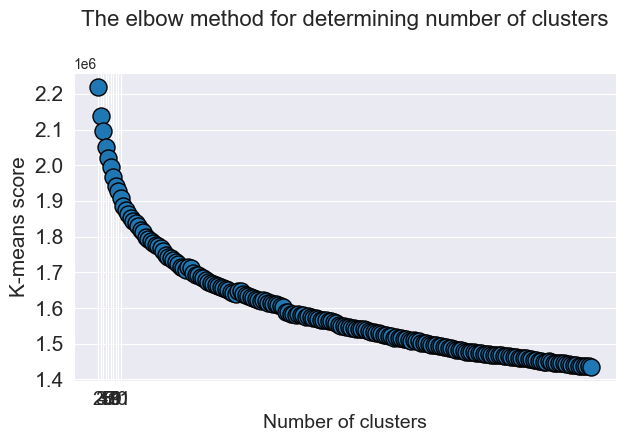

In [30]:
plt.figure(figsize=(7,4))
plt.title("The elbow method for determining number of clusters\n",fontsize=16)
plt.scatter(x=[i for i in range(2,200)],y=km_scores,s=150,edgecolor='k')
plt.grid(True)
plt.xlabel("Number of clusters",fontsize=14)
plt.ylabel("K-means score",fontsize=15)
plt.xticks([i for i in range(2,12)],fontsize=14)
plt.yticks(fontsize=15)
plt.show()

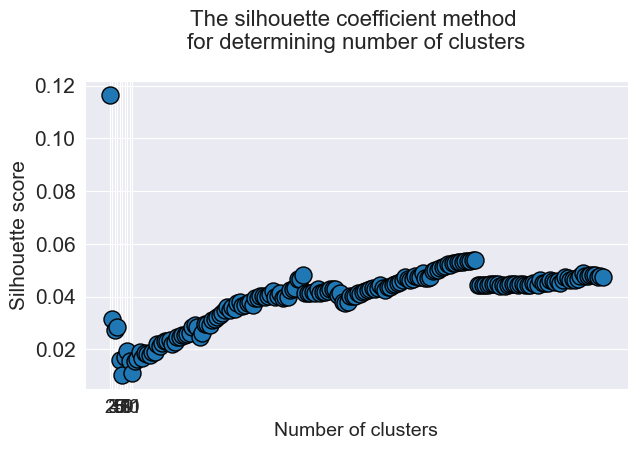

In [31]:
plt.figure(figsize=(7,4))
plt.title("The silhouette coefficient method \nfor determining number of clusters\n",fontsize=16)
plt.scatter(x=[i for i in range(2,200)],y=km_silhouette,s=150,edgecolor='k')
plt.grid(True)
plt.xlabel("Number of clusters",fontsize=14)
plt.ylabel("Silhouette score",fontsize=15)
plt.xticks([i for i in range(2,12)],fontsize=14)
plt.yticks(fontsize=15)
plt.show()

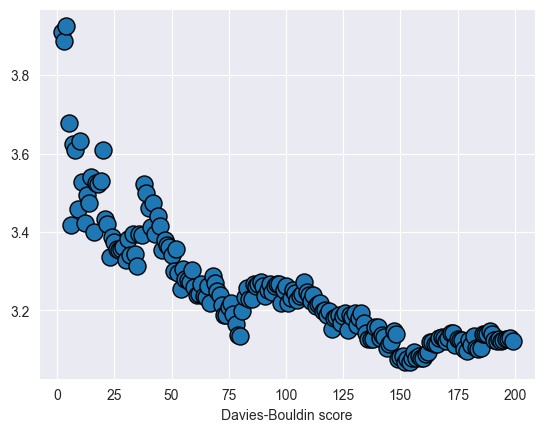

In [32]:
plt.scatter(x=[i for i in range(2,200)],y=db_score,s=150,edgecolor='k')
plt.grid(True)
plt.xlabel("Davies-Bouldin score")
plt.show()